# MLP FINAL
- Renskrevet version af 'mlp-v1'.
- Data klagøres i '00_data-prep'

- I denne notebook er der derfor kun:
- Encoding af features
- Afsøgning af hyperparametre
- Retraining på den bedste config
- Evaluering på test data

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.src.callbacks import early_stopping
from sklearn import preprocessing
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

DATA_DIR = Path('../data')
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 32
MAX_EPOCHS = 30
PATIENCE = 5

## 2. Load Data

- Datasættet er allerede splittet (64/16/20 - train/val/test) og stratified på target.
- Her loader vi data ind og verificerer shape er som forventet.

In [2]:
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze('columns')
y_val = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze('columns')
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze('columns')

y_train = (y_train == '>50K').astype(int)
y_val   = (y_val   == '>50K').astype(int)
y_test  = (y_test  == '>50K').astype(int)

# Positive rate er antallet af samples hvor y == 1 som er: >50K
# Hvis stratify har virket, skal fordelingen af targets være ca. det samme i hvert sæt.
print(f"train: {X_train.shape}      positive rate: {y_train.mean():.3f}")
print(f"val:   {X_val.shape}       positive rate: {y_val.mean():.3f}")
print(f"test:  {X_test.shape}       positive rate: {y_test.mean():.3f}")

train: (28941, 13)      positive rate: 0.248
val:   (7236, 13)       positive rate: 0.248
test:  (9045, 13)       positive rate: 0.248


## 3. Feature Encoding
- Numeriske features > StandardScalar
- Kategoriske features > OneHotEncoder
- Transformeren fittes kun på train, og bruges derefter til at tranformere val og test.
- Ellers leaker statistik fra val og test ind i train.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

preprocessor = ColumnTransformer([
      ('num', StandardScaler(),                          num_cols),
      ('cat', OneHotEncoder(handle_unknown='ignore'),    cat_cols),
  ])

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)


## 4. Model factory

`build_model(hp)` følger samme mønster som fra Fashion MNIST opgaven, men tilpasset binary classification og med dropout som ekstra HP.

## Metrics vs. objective:
- Vi logger accuracy, precision, recall og f1_score på hver epoch.
- Tuneren optimerer på val_f1_score.
- Som beskrevet i decisions.md bruger vi F1 (og recall/precision), fordi datasættet er ubalanceret (~25% positive).
- F1Score bruges som metric direkte i build_model med average='macro`, så den returnerer en skalar i stedet for et array.

In [4]:
import keras_tuner as kt

INPUT_DIM = X_train_enc.shape[1]

def build_model(hp):
    n_hidden      = hp.Int("n_hidden",     min_value=1,    max_value=4,    default=2)
    n_neurons     = hp.Int("n_neurons",    min_value=16,   max_value=256)
    dropout       = hp.Float("dropout",    min_value=0.0,  max_value=0.5,  step=0.1)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                             sampling="log")

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(INPUT_DIM,)))
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.F1Score(average="macro", threshold=0.5, name="f1_score"),
        ],
    )
    return model

## Hyperparametre
- Vi bruger RandomSearch som sampler tilfældige configs, og træner hver kombination op til MAX_EPOCHS
- Vi bruger EarlyStopping så vi ikke spilder compute på dårlige configs.

- Max Trials = 20
- Objective = val_f1_score (passer til vores valg af metric i `decisions.md`)
- seed = SEED
- overwrite = True (Ny søgning hver gang notebook kører)
- Artifakter gemmes i artifakter/mlp_final/

**EarlyStopping under tuning**
- Vi kigger på val_f1_score, og stopper hvis den ikke forbedres i 5 epochs.
- restore_best_weights = True, så vi bruger vægtene fra den bedste epoch, og ikke den sidste.


In [5]:
early_stopping = tf.keras.callbacks.EarlyStopping(
     monitor="val_f1_score",
     mode="max",
     patience=PATIENCE,
     restore_best_weights=True,
)

tuner = kt.RandomSearch(
     build_model,
     objective=kt.Objective("val_f1_score", direction="max"),
     max_trials=20,
     overwrite=True,
     directory=str(ARTIFACTS_DIR),
     project_name="mlp_final",
     seed=SEED,
)

tuner.search(
     X_train_enc, y_train,
     epochs=MAX_EPOCHS,
     batch_size=BATCH_SIZE,
     validation_data=(X_val_enc, y_val),
     callbacks=[early_stopping],
     verbose=1,
)

Trial 20 Complete [00h 00m 18s]
val_f1_score: 0.7090228796005249

Best val_f1_score So Far: 0.7090228796005249
Total elapsed time: 00h 10m 53s


In [6]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
for name, value in best_hp.values.items():
    print(f"  {name}: {value}")

Best hyperparameters:
  n_hidden: 3
  n_neurons: 239
  dropout: 0.2
  learning_rate: 0.00014948684422968163


## 6. Final training

- Vi har nu fundet de bedste hyperparametre. Vi bygger en frisk model med dem og træner den ordentligt færdig.
- tuner.get_best_models() returnerer modellen fra den bedste trial, men den trial blev kun trænet op til MAX_EPOCHS og EarlyStopping
- Test data bruges stadig ikke, kun train/val.

In [7]:
final_model = build_model(best_hp)
final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 239)            │        13,623 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 239)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 239)            │        57,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 239)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 239)            │        57,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 239)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,583 (502.28 KB)

 Trainable params: 128,583 (502.28 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
checkpoint_path = ARTIFACTS_DIR / "best_mlp.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_f1_score",
        mode="max",
        patience=PATIENCE,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_f1_score",
        mode="max",
        save_best_only=True,
    ),
]

history = final_model.fit(
    X_train_enc, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_enc, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8326 - f1_score: 0.6151 - loss: 0.3558 - precision: 0.7149 - recall: 0.5398 - val_accuracy: 0.8525 - val_f1_score: 0.7084 - val_loss: 0.3188 - val_precision: 0.6945 - val_recall: 0.7228
Epoch 2/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8482 - f1_score: 0.6685 - loss: 0.3259 - precision: 0.7286 - recall: 0.6176 - val_accuracy: 0.8541 - val_f1_score: 0.7057 - val_loss: 0.3150 - val_precision: 0.7053 - val_recall: 0.7061
Epoch 3/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8495 - f1_score: 0.6696 - loss: 0.3199 - precision: 0.7345 - recall: 0.6152 - val_accuracy: 0.8554 - val_f1_score: 0.7017 - val_loss: 0.3127 - val_precision: 0.7180 - val_recall: 0.6860
Epoch 4/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8515 - f1_score: 0.6747 - loss: 0.3172 - precision: 0.7380 - recall: 0.6215 - val_accuracy: 0.8553 - val_f1_score: 0.7004 - val_loss: 0.3115 - val_precision: 0.7192 - val_recall:

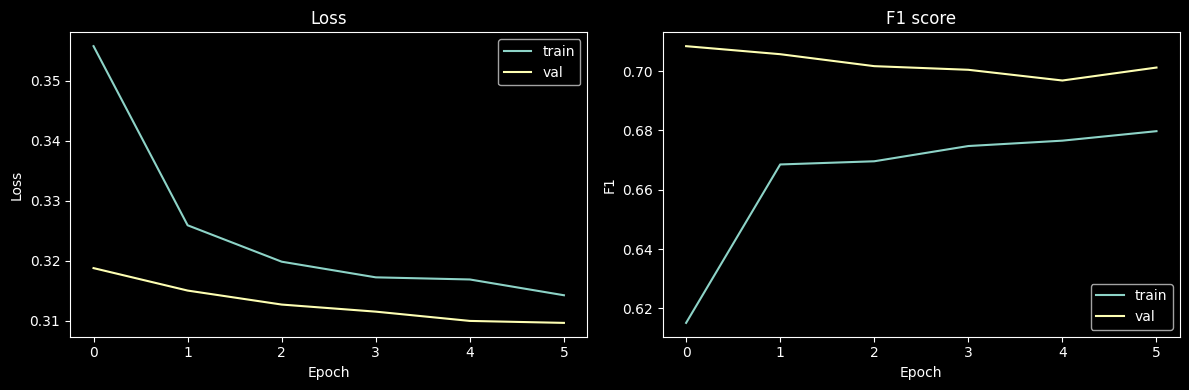

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].set_title("Loss")

axes[1].plot(history.history["f1_score"],     label="train")
axes[1].plot(history.history["val_f1_score"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1"); axes[1].legend()
axes[1].set_title("F1 score")

plt.tight_layout()
plt.show()

## 7. Test evaluation

Nu rører vi test-sættet for første gang. Vi loader den bedste model fra checkpoint (den med højeste `val_f1_score`) og rapporterer:

- **Precision, recall og F1 per klasse** — de metrics `decisions.md` peger på som relevante for et ubalanceret datasæt.
- **Confusion matrix** med TP/FP/FN/TN — viser hvor modellen rammer/fejler. Især interessant er false negatives (folk modellen tror tjener `<=50K`, men reelt tjener `>50K`) — det er den dyre fejl når positivklassen er den sjældne.

Threshold er sat til 0.5 (standard sigmoid cut-off).

             precision    recall        f1   support
<=50K            0.901     0.891     0.896      6803
>50K             0.680     0.704     0.692      2242


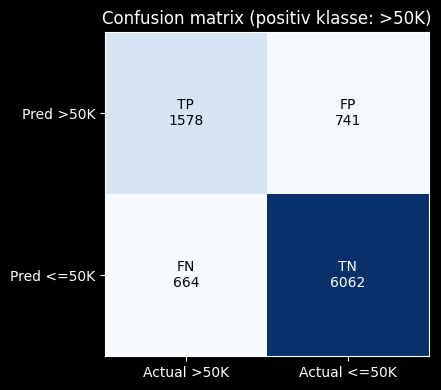

In [10]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Loader bedste model fra checkpoint
best_model = tf.keras.models.load_model(checkpoint_path)

# Predict på test
y_test_prob = best_model.predict(X_test_enc, verbose=0).ravel()
y_test_pred = (y_test_prob >= 0.5).astype(int)

# Printer precision, recall og f1 per klasse
prec, rec, f1, support = precision_recall_fscore_support(y_test, y_test_pred, labels=[0, 1])
print(f"{'':12}{'precision':>10}{'recall':>10}{'f1':>10}{'support':>10}")
for name, i in [('<=50K', 0), ('>50K', 1)]:
    print(f"{name:12}{prec[i]:>10.3f}{rec[i]:>10.3f}{f1[i]:>10.3f}{support[i]:>10}")

# Bygger confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
cm = np.array([[tp, fp],
               [fn, tn]])
labels = np.array([[f'TP\n{tp}', f'FP\n{fp}'],
                   [f'FN\n{fn}', f'TN\n{tn}']])

# Plotter confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Actual >50K', 'Actual <=50K'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Pred >50K', 'Pred <=50K'])
ax.set_title('Confusion matrix (positiv klasse: >50K)')
plt.tight_layout()
plt.show()